# Lab 03 — Can we trust this heart-rate summary?

We will use three minutes of heart-rate measurements, with one reading expected per second. Some messages have been repeated and others are missing. Start by inspecting the data, then remove the duplicates and check what is still missing.

Does a reasonable-looking average mean the data is complete?

The original measurements come from the public **BIDMC PPG and Respiration Dataset v1.0.0**, recording 01. The missing and repeated messages were introduced deliberately for this exercise. Time is elapsed recording time, not a patient's calendar timestamp. See `data/README.md` for provenance and licence information.

## 1. Read the received measurements

Run each cell in order with **Shift+Enter**, or use **Run → Run All Cells**. The two columns are elapsed seconds and heart rate in beats per minute. Start by inspecting the first rows.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path('data')
received = pd.read_csv(DATA / 'received.csv')
received.head(12)

,elapsed_seconds,heart_rate_bpm
0,0,94.0
1,1,94.0
2,2,94.0
3,3,92.0
4,4,93.0
5,5,93.0
6,6,94.0
7,7,94.0
8,8,94.0
9,9,94.0


## 2. What would we expect?

Three minutes at one measurement per second means **180 distinct timestamps**, from 0 through 179. Counting rows does not tell us how many distinct measurements arrived.

Before running the cell, predict: can a file contain duplicates and missing readings at the same time?

In [2]:
expected_seconds = pd.Index(range(180), name='elapsed_seconds')
extra_rows = received.duplicated(subset='elapsed_seconds').sum()
missing_seconds = expected_seconds.difference(received['elapsed_seconds'])
print(f'Received rows: {len(received)}')
print(f'Extra rows sharing an existing timestamp: {extra_rows}')
print(f'Missing timestamps: {len(missing_seconds)}')
print('Missing seconds:', missing_seconds.tolist())

Received rows: 175
Extra rows sharing an existing timestamp: 10
Missing timestamps: 15
Missing seconds: [75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]


## 3. Inspect before removing

For this recording, each timestamp should identify one observation. Our repeated messages are exact copies. If two readings at the same timestamp disagreed, keeping the first would need a separate justification.

In [3]:
duplicates = received[received.duplicated('elapsed_seconds', keep=False)]
duplicates.head(8)

,elapsed_seconds,heart_rate_bpm
20,20,94.0
21,20,94.0
22,21,94.0
23,21,94.0
24,22,94.0
25,22,94.0
26,23,94.0
27,23,94.0


## 4. Remove exact duplicates and flag the gaps

We retain one copy of each identical row. Reindexing to the expected seconds makes absent readings visible as `NaN` (missing). We do **not** invent replacement values or replace gaps with zero.

In [4]:
cleaned = received.drop_duplicates().set_index('elapsed_seconds')
assert cleaned.index.is_unique, 'Conflicting readings need an explicit policy.'
cleaned = cleaned.reindex(expected_seconds)
cleaned['missing_reading'] = cleaned['heart_rate_bpm'].isna()
cleaned.loc[70:92]

,heart_rate_bpm,missing_reading
elapsed_seconds,,
70,91.0,False
71,91.0,False
72,91.0,False
73,91.0,False
74,91.0,False
75,NaN,True
76,NaN,True
77,NaN,True
78,NaN,True


## 5. Compare averages with available readings

The helper below groups seconds 0–59, 60–119 and 120–179. Pandas computes the mean over available values, ignoring missing ones.

The reference file contains the original three-minute excerpt before our deliberate changes. It helps us understand this exercise; a real ingestion system may not have a complete reference.

In [5]:
reference = pd.read_csv(DATA / 'reference.csv')

def minute_summary(frame):
    work = frame.copy()
    work['minute'] = work['elapsed_seconds'] // 60 + 1
    return work.groupby('minute')['heart_rate_bpm'].agg(mean_bpm='mean', available_readings='count').reindex([1, 2, 3])

before = minute_summary(received)
after = minute_summary(cleaned.reset_index())
baseline = minute_summary(reference)
comparison = pd.DataFrame({
    'received_mean_bpm': before['mean_bpm'],
    'cleaned_mean_bpm': after['mean_bpm'],
    'reference_mean_bpm': baseline['mean_bpm'],
    'received_rows': before['available_readings'],
    'available_readings': after['available_readings'],
    'expected_readings': 60,
})
comparison['coverage_percent'] = 100 * comparison['available_readings'] / 60
comparison.round(2)

,received_mean_bpm,cleaned_mean_bpm,reference_mean_bpm,received_rows,available_readings,expected_readings,coverage_percent
minute,,,,,,,
1,93.21,93.08,93.08,70,60,60,100.0
2,91.58,91.58,91.43,45,45,60,75.0
3,91.33,91.33,91.33,60,60,60,100.0


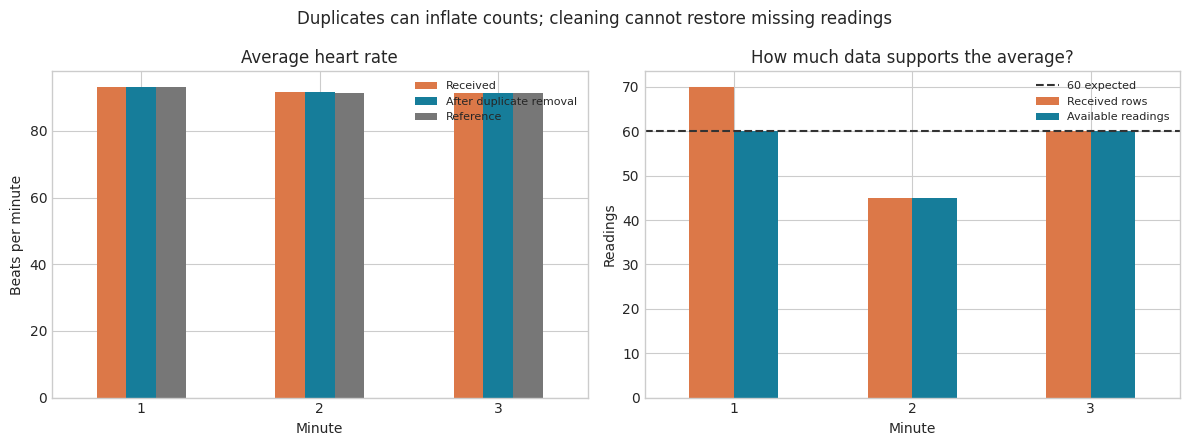

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
comparison[['received_mean_bpm', 'cleaned_mean_bpm', 'reference_mean_bpm']].plot.bar(
    ax=axes[0], color=['#dc7848', '#167d9a', '#777777'], rot=0)
axes[0].set(title='Average heart rate', xlabel='Minute', ylabel='Beats per minute')
axes[0].legend(['Received', 'After duplicate removal', 'Reference'], fontsize=8)
comparison[['received_rows', 'available_readings']].plot.bar(
    ax=axes[1], color=['#dc7848', '#167d9a'], rot=0)
axes[1].axhline(60, color='#333333', linestyle='--', label='60 expected')
axes[1].set(title='How much data supports the average?', xlabel='Minute', ylabel='Readings')
axes[1].legend(['60 expected', 'Received rows', 'Available readings'], fontsize=8)
fig.suptitle('Duplicates can inflate counts; cleaning cannot restore missing readings', fontsize=12)
fig.tight_layout()
Path('outputs').mkdir(exist_ok=True)
fig.savefig('outputs/comparison.png', dpi=160, bbox_inches='tight')
comparison.to_csv('outputs/comparison.csv')
plt.show()

## 6. Explain what happened

1. Which minute had duplicate messages? Which minute had missing messages?
2. Does removing duplicates give us all 180 observations back? Explain.
3. Can an average look reasonable while its coverage is poor?
4. Why would replacing missing heart rates with zero change the meaning of the data?

**Your answer:** write a short explanation here and refer to the table or plot. If the average barely changes, explain why checking the reading count still matters.

## Optional exercise — Flag incomplete minutes

Change the threshold below to flag any minute with fewer than **54 of 60** readings. Run the cell and explain what changes if you instead require all 60 readings. This marks uncertainty; it does not repair missing observations.

In [7]:
minimum_readings = 54
comparison['needs_review'] = comparison['available_readings'] < minimum_readings
comparison[['available_readings', 'coverage_percent', 'needs_review']]

,available_readings,coverage_percent,needs_review
minute,,,
1,60,100.0,False
2,45,75.0,True
3,60,100.0,False


## Summary

The average alone does not tell us whether all the readings arrived. Include the reading count or coverage when reporting it, and explain how you handled duplicates and missing values.

### Sources

- [BIDMC dataset v1.0.0](https://physionet.org/content/bidmc/1.0.0/), Pimentel, Johnson, Charlton and Clifton.
- Pimentel et al., *Towards a Robust Estimation of Respiratory Rate from Pulse Oximeters*, DOI [10.1109/TBME.2016.2613124](https://doi.org/10.1109/TBME.2016.2613124).
- Dataset attribution and modification details: `data/README.md`.